# 02 - Verifica CLIP retrieval

Obiettivo: costruire l'indice CLIP configurato per l'Esercizio 3.3 e controllare il comportamento del ranking su query testuali rappresentative.

## Setup

Il notebook usa lo stesso modulo e la stessa configurazione dell'app Gradio, quindi i risultati sono coerenti con l'interfaccia finale.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display
from omegaconf import OmegaConf

# Risale le cartelle padre finché non trova DLA_LAB2, indipendentemente da dove Jupyter è stato avviato.
project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "DLA_LAB2").exists())
lab2_dir = project_root / "DLA_LAB2"
exercise_dir = lab2_dir / "exercise_3_3_clip_retrieval"
if str(lab2_dir) not in sys.path:
    sys.path.insert(0, str(lab2_dir))

from src.clip_retrieval import build_clip_retrieval_system
from src.utils import get_device

cfg = OmegaConf.load(exercise_dir / "config.yaml")
device = get_device()
device

device(type='cuda')

## Costruzione dell'indice

La prima esecuzione calcola gli embedding visuali e li salva in cache. Le esecuzioni successive ricaricano la cache se la configurazione non cambia.

In [2]:
cache_path = exercise_dir / str(cfg.output.dir) / str(cfg.output.cache_file)
system = build_clip_retrieval_system(
    dataset_name=str(cfg.dataset.name),
    split=str(cfg.dataset.split),
    model_name=str(cfg.model.name),
    max_images=int(cfg.dataset.max_images),
    seed=int(cfg.dataset.seed),
    cache_path=cache_path,
    device=device,
    image_batch_size=int(cfg.model.image_batch_size),
)

index_info = pd.DataFrame(
    {
        "campo": ["dataset", "split", "modello", "immagini indicizzate", "cache", "device"],
        "valore": [
            system.index.metadata["dataset_name"],
            system.index.metadata["split"],
            system.index.metadata["model_name"],
            len(system.index.records),
            str(cache_path),
            str(device),
        ],
    }
)
index_info

Preparing image records:   0%|          | 0/1000 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/32 [00:00<?, ?it/s]

,campo,valore
0,dataset,jxie/flickr8k
1,split,train
2,modello,openai/clip-vit-base-patch32
3,immagini indicizzate,1000
4,cache,c:\Users\franc\Desktop\Git_Hub_Deep_Learning-A...
5,device,cuda


## Query qualitative

La verifica e' qualitativa: CLIP non viene fine-tunato, quindi ci aspettiamo matching semantici ragionevoli ma non perfetti.

In [3]:
queries = [
    "a dog running through water",
    "a child in a red shirt",
    "people playing football on a field",
]

rows = []
for query in queries:
    for result in system.search(query=query, top_k=5):
        rows.append(
            {
                "query": query,
                "rank": result.rank,
                "score": result.score,
                "item_id": result.record.item_id,
                "caption": result.record.caption,
            }
        )

results_df = pd.DataFrame(rows)
results_df

,query,rank,score,item_id,caption
0,a dog running through water,1,0.340237,train-872,"A brown and white dog , wearing a collar , is ..."
1,a dog running through water,2,0.335215,train-179,A big dog shakes itself dry while standing in ...
2,a dog running through water,3,0.329767,train-822,A big tan wet dog in shallow water .
3,a dog running through water,4,0.327509,train-117,a black and white colored dog jumping around i...
4,a dog running through water,5,0.318592,train-890,A big tan dog jumps in the water .
5,a child in a red shirt,1,0.298325,train-778,A boy smiles at the camera .
6,a child in a red shirt,2,0.290735,train-298,A boy goes down an inflatable slide .
7,a child in a red shirt,3,0.281610,train-550,A baby in a Santa hat holds a Santa figure whi...
8,a child in a red shirt,4,0.276790,train-487,A child stands near a fence .
9,a child in a red shirt,5,0.275563,train-101,A child peeks his head out from some flowers .


Query: a dog running through water
  #1 score=0.340 | A brown and white dog , wearing a collar , is moving through some water .
  #2 score=0.335 | A big dog shakes itself dry while standing in a creek .
  #3 score=0.330 | A big tan wet dog in shallow water .


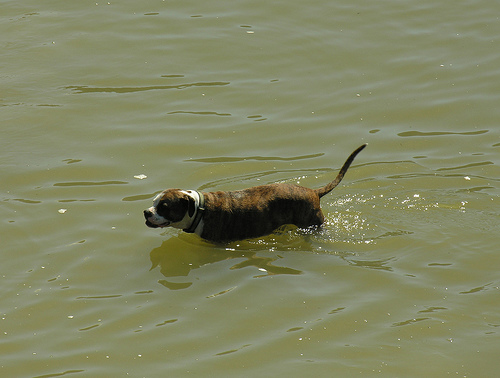

Query: a child in a red shirt
  #1 score=0.298 | A boy smiles at the camera .
  #2 score=0.291 | A boy goes down an inflatable slide .
  #3 score=0.282 | A baby in a Santa hat holds a Santa figure while laying on a brown sofa .


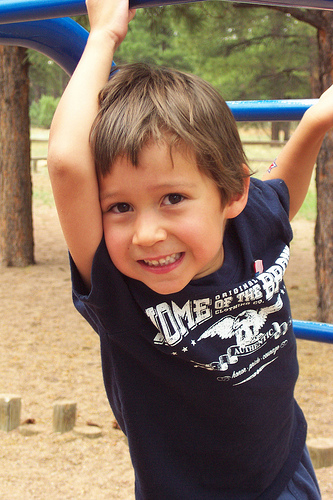

Query: people playing football on a field
  #1 score=0.303 | A gorup of boys are playing with a ball in front of a large wooden door .
  #2 score=0.295 | A boy and a dog are running down a hill away from a crowd .
  #3 score=0.292 | a boy jumps on another boy .


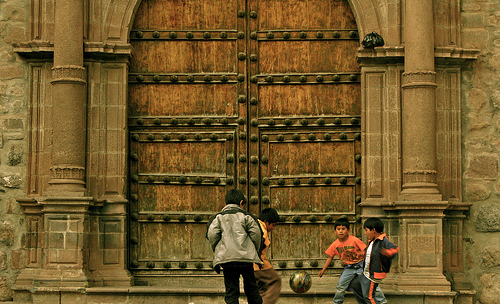

In [4]:
for query in queries:
    print(f"Query: {query}")
    for result in system.search(query=query, top_k=3):
        print(f"  #{result.rank} score={result.score:.3f} | {result.record.caption}")
    display(system.search(query=query, top_k=1)[0].record.image)


## Osservazioni

L'indice e' stato costruito su 1000 immagini di `jxie/flickr8k` usando `openai/clip-vit-base-patch32` su device `cuda` (rilevato automaticamente da `get_device`; su macOS con Apple Silicon sarebbe `mps`). La cache locale degli embedding e' stata salvata in `outputs/clip_retrieval/clip_index.pt` e viene riusata nelle esecuzioni successive.

La query `a dog running through water` restituisce risultati molto coerenti: il primo risultato ha score 0.340 e caption `A brown and white dog , wearing a collar , is moving through some water .`. La query `a child in a red shirt` recupera immagini di bambini, ma non sempre preserva il vincolo cromatico. La query `people playing football on a field` mostra il limite principale del sistema zero-shot su subset piccolo: recupera scene con persone e palla, ma non necessariamente un campo da football.